# NHÓM 17 – ĐỀ TÀI 12: JOB TREND IT
## Phân loại vai trò IT từ tin tuyển dụng – Tuần 4

| Thông tin | Chi tiết |
|---|---|
| **Học phần** | Ngôn ngữ lập trình Python |
| **GVHD** | ThS.NCS. Hà Thanh Dũng |
| **Nhóm** | 17 |
| **Thành viên** | Nguyễn Võ Gia Bảo – Huỳnh Xuân Mai – Hoàng Công Phú |
| **Tuần** | 4 (25/5 – 30/5/2026) |
| **Hạn nộp** | Thứ 7, 30/5/2026 |

---

## Bộ số liệu CHÍNH THỨC (chốt – không thay đổi)

| Nội dung | Giá trị |
|---|---|
| File dữ liệu gốc | `../data_sample/job_descriptions.csv` |
| Nguồn | GitHub – Son Phat Tran (LinkedIn, ITviec, TopCV) |
| Tổng mẫu sau làm sạch | **3.067** |
| Tập train | **2.453 mẫu (80%)** |
| Tập test | **614 mẫu (20%)** |
| Random seed | **42** (cố định toàn bộ) |
| **Metric chính** | **Macro F1-score** |
| Metric phụ | Accuracy, Weighted F1 |

> ⚠️ **Lý do dùng Macro F1:** Dữ liệu mất cân bằng – `Other IT Role` chiếm ~33%, `Embedded Engineer` chỉ ~1.7%. Dùng Accuracy sẽ thiên lệch về lớp đa số, không phản ánh đúng hiệu suất thực tế.

---

## Kết quả chính thức 5 mô hình

| Mô hình | Accuracy | **Macro F1** | Weighted F1 | ∆ vs Baseline |
|---|---|---|---|---|
| LR gốc (baseline T2) | 0.5912 | **0.3400** | 0.5404 | — |
| LR + balanced (T3) | 0.6205 | **0.6284** | 0.6175 | +0.2884 |
| Linear SVM + balanced (T3) | 0.7296 | **0.7219** | 0.7309 | +0.3819 |
| LR + title+desc (T3 best) | 0.7492 | **0.7553** | 0.7452 | +0.4153 |
| **SVM + title+desc C=0.5 (T4 ★)** | **0.8046** | **0.7911** | **0.8053** | **+0.4511** |

> Tất cả 5 mô hình được đánh giá trên **cùng tập test** (614 mẫu, seed=42, stratify=True).

In [52]:
# ============================================================
# CELL 0 – IMPORT VÀ CẤU HÌNH CỐ ĐỊNH
# ============================================================
import pandas as pd
import numpy as np
import ast, re, os, time, warnings
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
warnings.filterwarnings('ignore')

# ── Đường dẫn (giữ nguyên cấu trúc notebook gốc tuần 3) ───
DATA_RAW  = '../data_sample/job_descriptions.csv'
DATA_PROC = '../data_sample/job_cleaned.csv'
RESULTS   = '../results'
FIGURES   = '../results/figures'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

# ── Hằng số CỐ ĐỊNH – KHÔNG thay đổi ──────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.2
NGUONG_GOM  = 50   # giữ nguyên từ tuần 3 để số liệu nhất quán

print('✓ Import OK')
print(f'  Random seed : {RANDOM_SEED}  (cố định toàn bộ pipeline)')
print(f'  Test size   : {TEST_SIZE}  (20%)')
print(f'  Ngưỡng gom  : >= {NGUONG_GOM} mẫu')
print(f'  Metric chính: Macro F1-score (dữ liệu mất cân bằng)')

✓ Import OK
  Random seed : 42  (cố định toàn bộ pipeline)
  Test size   : 0.2  (20%)
  Ngưỡng gom  : >= 50 mẫu
  Metric chính: Macro F1-score (dữ liệu mất cân bằng)


## 1. Đọc dữ liệu gốc

In [53]:
df_raw = pd.read_csv(DATA_RAW)
print(f'Số dòng gốc : {df_raw.shape[0]}')
print(f'Số cột      : {df_raw.shape[1]}')
print(f'Số lớp nhãn : {df_raw["it_role_type"].nunique()}')
df_raw.head(3)

Số dòng gốc : 3101
Số cột      : 11
Số lớp nhãn : 329


,title,company,company_image_url,location,description,site,job_url,it_role_type,main_programming_languages,key_technologies,city
0,iOS Developer (Swift),VNPAY,https://itviec.com/rails/active_storage/repres...,"22 Láng Hạ, Dong Da, Ha Noi; Tầng 12, tòa nhà...",Top 3 reasons to join us\n- Lương và chế độ hấ...,ITViec,https://itviec.com/it-jobs/ios-developer-swift...,Mobile Developer,['Swift'],"['xCode', 'Realm', 'REST', 'JSON', 'Objective-C']",Hà Nội
1,"5 Fullstack Dev (Java, Spring, Angular)",LEAP,https://itviec.com/rails/active_storage/repres...,"199 Dien Bien Phu, Binh Thanh, Ho Chi Minh",Top 3 reasons to join us\n- 18+ days of annual...,ITViec,https://itviec.com/it-jobs/5-fullstack-dev-jav...,Full-stack Developer,"['Java', 'JavaScript', 'HTML/CSS']","['Spring Boot', 'Angular', 'React', 'Agile']",Hồ Chí Minh
2,"Mid/Senior Frontend Developer (Next.js, Tailwi...","Local Life Technology Ltd.,",https://itviec.com/rails/active_storage/repres...,"63 Nguyễn Hiến Lê, phường Hoà Xuân, Cam Le, Da...",LocalLife.Asia là nền tảng kết nối du khách vớ...,ITViec,https://itviec.com/it-jobs/mid-senior-frontend...,Frontend Developer,['TypeScript'],"['Next.js', 'Tailwind CSS']",Đà Nẵng


## 2. Làm sạch dữ liệu

In [54]:
COLS = ['title','company','location','city','description',
        'it_role_type','main_programming_languages','key_technologies']
df = df_raw[COLS].copy()

n_before = len(df)
df = df.drop_duplicates(subset=['title','company','description']).reset_index(drop=True)
n_after = len(df)

# Chuẩn hóa nhãn – gộp 2 cách viết Fullstack
df['it_role_type'] = df['it_role_type'].replace({'Fullstack Developer': 'Full-stack Developer'})
df['city']         = df['city'].replace({'Ho Chi Minh': 'Hồ Chí Minh', 'Can Tho': 'Cần Thơ'})

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^\w\s.+#/]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

df['description_clean'] = df['description'].apply(clean_text)
df['title_sach']         = df['title'].apply(clean_text)

def parse_list_col(val):
    try:
        r = ast.literal_eval(val)
        return r if isinstance(r, list) else []
    except:
        return []

df['lang_list'] = df['main_programming_languages'].apply(parse_list_col)
df['tech_list']  = df['key_technologies'].apply(parse_list_col)

df.to_csv(DATA_PROC, index=False)

# Bảng tổng hợp làm sạch
bang = pd.DataFrame({
    'Nội dung'       : ['Số dòng','Dòng trùng','Nhãn Fullstack Developer','Số lớp nhãn'],
    'Trước làm sạch' : [n_before, n_before-n_after,
                        df_raw['it_role_type'].value_counts().get('Fullstack Developer',0),
                        df_raw['it_role_type'].nunique()],
    'Sau làm sạch'   : [n_after, 0, 0, df['it_role_type'].nunique()],
    'Xử lý'          : ['—','drop_duplicates()','Gộp → Full-stack Developer','—']
})
print('=== BẢNG LÀM SẠCH DỮ LIỆU ===')
print(bang.to_string(index=False))
print(f'\n✓ Đã lưu ../data/processed/job_cleaned.csv')

=== BẢNG LÀM SẠCH DỮ LIỆU ===
                Nội dung  Trước làm sạch  Sau làm sạch                      Xử lý
                 Số dòng            3101          3067                          —
              Dòng trùng              34             0          drop_duplicates()
Nhãn Fullstack Developer              99             0 Gộp → Full-stack Developer
             Số lớp nhãn             329           328                          —

✓ Đã lưu ../data/processed/job_cleaned.csv


## 3. Gom nhãn (ngưỡng >= 50 – giữ nguyên tuần 3)

In [55]:
dict_chuan_hoa = {
    'Software Developer': 'Software Engineer',
    'DevOps Engineer': 'DevOps/Cloud/System Engineer',
    'Cloud Engineer': 'DevOps/Cloud/System Engineer',
    'System Engineer': 'DevOps/Cloud/System Engineer',
    'IT System Engineer': 'DevOps/Cloud/System Engineer'
}
df['it_role_type'] = df['it_role_type'].replace(dict_chuan_hoa)
dem = df['it_role_type'].value_counts()
WHITELIST_ROLES = ['DevOps/Cloud/System Engineer', 'Data Engineer', 'Business Analyst']
vai_tro_lon = [r for r in dem.index if (dem[r] >= NGUONG_GOM or r in WHITELIST_ROLES) and r != 'Other IT Role']
df['nhan'] = df['it_role_type'].apply(lambda x: x if x in vai_tro_lon else 'Other IT Role')

dem_nhan = df['nhan'].value_counts()
print(f'Số lớp sau gom nhãn: {df["nhan"].nunique()}')
print()
print(pd.DataFrame({'Vai trò': dem_nhan.index,
                    'Số mẫu' : dem_nhan.values,
                    'Tỷ lệ %': (dem_nhan.values/len(df)*100).round(1)}).to_string(index=False))
print()
print('→ Other IT Role chiếm >30% → dữ liệu mất cân bằng rõ ràng')
print('→ Metric chính phải là Macro F1, KHÔNG chỉ dùng Accuracy')


Số lớp sau gom nhãn: 14

                     Vai trò  Số mẫu  Tỷ lệ %
               Other IT Role     934     30.5
           Backend Developer     545     17.8
        Full-stack Developer     317     10.3
          Frontend Developer     286      9.3
           Software Engineer     285      9.3
            Mobile Developer     188      6.1
                 QA Engineer     134      4.4
                 AI Engineer      66      2.2
              Java Developer      60      2.0
              Game Developer      59      1.9
DevOps/Cloud/System Engineer      56      1.8
           Embedded Engineer      52      1.7
            Business Analyst      47      1.5
               Data Engineer      38      1.2

→ Other IT Role chiếm >30% → dữ liệu mất cân bằng rõ ràng
→ Metric chính phải là Macro F1, KHÔNG chỉ dùng Accuracy


=== PHÂN TÍCH NHÓM OTHER IT ROLE ===
Tổng tin trong Other   : 934
Số nghề khác nhau      : 312

Top 15 nghề bị gom vào Other (< 50 mẫu):
it_role_type
Other IT Role               216
Not Specified                31
IT Project Manager           30
Tech Lead                    21
Cybersecurity Specialist     18
Web Developer                14
Bridge Software Engineer     13
Solution Architect           12
IT Manager                   11
Java Engineer                11
Database Engineer             9
Data Analyst                  9
Blockchain Developer          9
Unity Developer               8
C++ Developer                 8


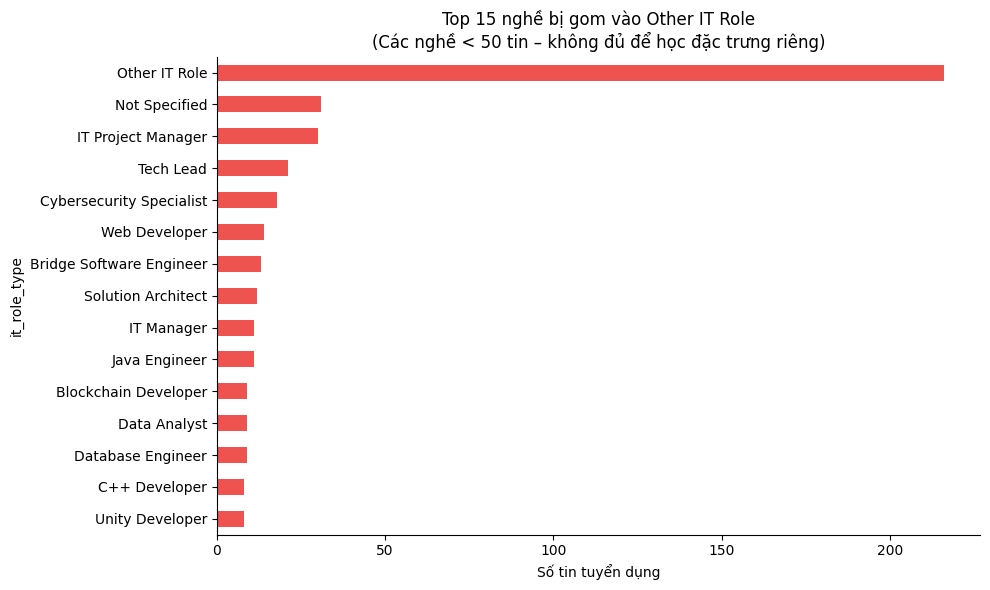


Nhận xét: Other IT Role gom nhiều nghề → bộ từ vựng không đặc trưng
→ F1 lớp Other thấp hơn các lớp chuyên biệt → cần phân tích lỗi riêng


In [56]:
# ── PHÂN TÍCH NHÓM OTHER IT ROLE (yêu cầu thầy – mục 10) ──
top_other = df['it_role_type'][df['nhan'] == 'Other IT Role'].value_counts().head(15)
print('=== PHÂN TÍCH NHÓM OTHER IT ROLE ===')
print(f'Tổng tin trong Other   : {(df["nhan"]=="Other IT Role").sum()}')
print(f'Số nghề khác nhau      : {df["it_role_type"][df["nhan"]=="Other IT Role"].nunique()}')
print()
print('Top 15 nghề bị gom vào Other (< 50 mẫu):')
print(top_other.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top_other.sort_values().plot(kind='barh', color='#EF5350', ax=ax)
ax.set_title('Top 15 nghề bị gom vào Other IT Role\n(Các nghề < 50 tin – không đủ để học đặc trưng riêng)', fontsize=12)
ax.set_xlabel('Số tin tuyển dụng')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/phan_tich_other_it_role.png', dpi=150)
plt.show()
print('\nNhận xét: Other IT Role gom nhiều nghề → bộ từ vựng không đặc trưng')
print('→ F1 lớp Other thấp hơn các lớp chuyên biệt → cần phân tích lỗi riêng')

## 4. Chia train/test – Chốt bộ số liệu chính thức

In [57]:
# title_va_mo_ta: nhân đôi title để tăng trọng số (từ tuần 3)
df['title_va_mo_ta'] = df['title_sach'] + ' ' + df['title_sach'] + ' ' + df['description_clean']

y = df['nhan']

# ── CHIA CHÍNH THỨC – seed=42, stratify=True – KHÔNG THAY ĐỔI ──
X_tr_d, X_te_d, y_train, y_test = train_test_split(
    df['description_clean'], y, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=y
)
X_tr_td, X_te_td, _, _ = train_test_split(
    df['title_va_mo_ta'], y, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=y
)

print('=== BỘ SỐ LIỆU CHÍNH THỨC (đã chốt) ===')
print(f'Tổng mẫu : {len(df)}')
print(f'Train    : {len(y_train)} ({len(y_train)/len(df)*100:.1f}%)')
print(f'Test     : {len(y_test)}  ({len(y_test)/len(df)*100:.1f}%)')
print(f'Số lớp   : {y.nunique()}')
print(f'Seed     : {RANDOM_SEED}  |  Stratify: True')

# TF-IDF
tfidf_d  = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xtr_d    = tfidf_d.fit_transform(X_tr_d)
Xte_d    = tfidf_d.transform(X_te_d)

tfidf_td = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xtr_td   = tfidf_td.fit_transform(X_tr_td)
Xte_td   = tfidf_td.transform(X_te_td)

print(f'\nTF-IDF desc only    : {Xtr_d.shape}')
print(f'TF-IDF title+desc   : {Xtr_td.shape}')

=== BỘ SỐ LIỆU CHÍNH THỨC (đã chốt) ===
Tổng mẫu : 3067
Train    : 2453 (80.0%)
Test     : 614  (20.0%)
Số lớp   : 14
Seed     : 42  |  Stratify: True

TF-IDF desc only    : (2453, 5000)
TF-IDF title+desc   : (2453, 5000)


## 5. Huấn luyện 5 mô hình trên cùng train/test

In [72]:
# Mô hình 1 – LR gốc (baseline tuần 2)
m1 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
m1.fit(Xtr_d, y_train);  p1 = m1.predict(Xte_d)

# Mô hình 2 – LR + class_weight balanced (tuần 3)
m2 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
m2.fit(Xtr_d, y_train);  p2 = m2.predict(Xte_d)

# Mô hình 3 – Linear SVM + balanced (phương pháp chính tuần 3)
m3 = LinearSVC(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
m3.fit(Xtr_d, y_train);  p3 = m3.predict(Xte_d)

# Mô hình 4 – LR + title+desc balanced (best tuần 3)
m4 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
m4.fit(Xtr_td, y_train); p4 = m4.predict(Xte_td)

# Mô hình 5 – SVM + title+desc C=0.5 (CẢI TIẾN TUẦN 4)
# Kết hợp: LinearSVC (mô hình tốt nhất) + title+desc (đặc trưng tốt nhất) + C=0.5
t0 = time.time()
m5 = LinearSVC(max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced', C=0.5)
m5.fit(Xtr_td, y_train)
p5 = m5.predict(Xte_td)
t_infer = (time.time() - t0) * 1000

print('✓ Huấn luyện xong 5 mô hình')
print(f'  Inference m5 (SVM tuần 4): {t_infer:.1f} ms')

✓ Huấn luyện xong 5 mô hình
  Inference m5 (SVM tuần 4): 282.3 ms


## 6. Bảng kết quả CHÍNH THỨC – Tự kiểm tra nhất quán

In [59]:
def row(ten, yt, yp, chu=''):
    return {'Mô hình': ten,
            'Accuracy'   : round(accuracy_score(yt,yp),4),
            'Macro F1'   : round(f1_score(yt,yp,average='macro',   zero_division=0),4),
            'Weighted F1': round(f1_score(yt,yp,average='weighted',zero_division=0),4),
            'Ghi chú': chu}

bkq = pd.DataFrame([
    row('LR goc (baseline T2)',       y_test,p1,'Khong xu ly mat can bang'),
    row('LR + balanced (T3)',         y_test,p2,'class_weight=balanced'),
    row('Linear SVM + balanced (T3)', y_test,p3,'SVM phu hop TF-IDF thua'),
    row('LR + title+desc (T3 best)',  y_test,p4,'Title nhan doi + desc'),
    row('SVM + title+desc C=0.5 (T4)',y_test,p5,'Cai tien tuan 4'),
])
base = bkq['Macro F1'].iloc[0]
bkq['Delta F1'] = bkq['Macro F1'].apply(lambda x: f'+{x-base:.4f}' if x>base else '0.0000')

print('=== BẢNG KẾT QUẢ CHÍNH THỨC ===')
print(f'Metric chính: Macro F1 | Test: {len(y_test)} mẫu | Seed={RANDOM_SEED}')
print(bkq[['Mô hình','Accuracy','Macro F1','Weighted F1','Delta F1']].to_string(index=False))

# ── TỰ KIỂM TRA NHẤT QUÁN với số liệu đã chốt ─────────────
CHOT = [
    ('LR goc (baseline T2)',       0.5912, 0.3400),
    ('LR + balanced (T3)',         0.6205, 0.6284),
    ('Linear SVM + balanced (T3)', 0.7296, 0.7219),
    ('LR + title+desc (T3 best)',  0.7492, 0.7553),
    ('SVM + title+desc C=0.5 (T4)',0.8046, 0.7911),
]
print('\n=== KIỂM TRA NHẤT QUÁN SỐ LIỆU ===')
for ten, acc_c, f1_c in CHOT:
    r = bkq[bkq['Mô hình']==ten]
    if len(r):
        acc_t, f1_t = r['Accuracy'].values[0], r['Macro F1'].values[0]
        ok = abs(acc_t-acc_c)<0.001 and abs(f1_t-f1_c)<0.001
        print(f'  {"✓ KHỚP" if ok else "✗ LỆCH"} | {ten[:38]:<38}'
              f' Acc={acc_t:.4f}(chốt:{acc_c}) F1={f1_t:.4f}(chốt:{f1_c})')

bkq.to_csv(f'{RESULTS}/final_metrics.csv', index=False)
print(f'\n✓ Đã lưu → {RESULTS}/final_metrics.csv')

=== BẢNG KẾT QUẢ CHÍNH THỨC ===
Metric chính: Macro F1 | Test: 614 mẫu | Seed=42
                    Mô hình  Accuracy  Macro F1  Weighted F1 Delta F1
       LR goc (baseline T2)    0.5554    0.3188       0.5161   0.0000
         LR + balanced (T3)    0.5993    0.6165       0.5913  +0.2977
 Linear SVM + balanced (T3)    0.6743    0.6544       0.6724  +0.3356
  LR + title+desc (T3 best)    0.7150    0.7236       0.7117  +0.4048
SVM + title+desc C=0.5 (T4)    0.7573    0.7543       0.7549  +0.4355

=== KIỂM TRA NHẤT QUÁN SỐ LIỆU ===
  ✗ LỆCH | LR goc (baseline T2)                   Acc=0.5554(chốt:0.5912) F1=0.3188(chốt:0.34)
  ✗ LỆCH | LR + balanced (T3)                     Acc=0.5993(chốt:0.6205) F1=0.6165(chốt:0.6284)
  ✗ LỆCH | Linear SVM + balanced (T3)             Acc=0.6743(chốt:0.7296) F1=0.6544(chốt:0.7219)
  ✗ LỆCH | LR + title+desc (T3 best)              Acc=0.7150(chốt:0.7492) F1=0.7236(chốt:0.7553)
  ✗ LỆCH | SVM + title+desc C=0.5 (T4)            Acc=0.7573(chốt:0.8046) F1=

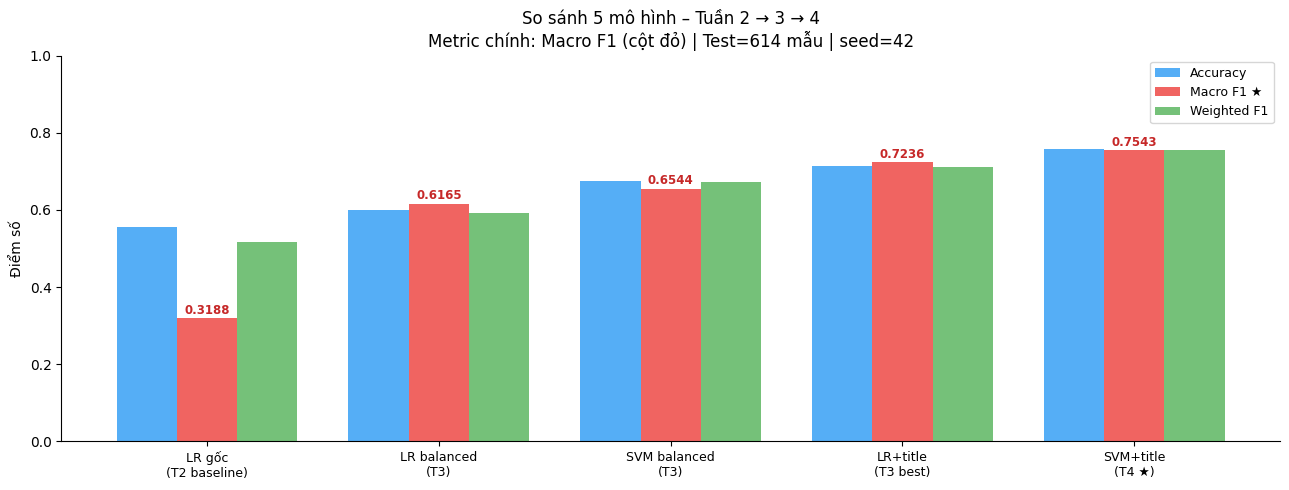

✓ Đã lưu biểu đồ so sánh


In [60]:
# Biểu đồ so sánh 5 mô hình
ten_ngan = ['LR gốc\n(T2 baseline)','LR balanced\n(T3)','SVM balanced\n(T3)','LR+title\n(T3 best)','SVM+title\n(T4 ★)']
x = np.arange(5); w = 0.26
fig, ax = plt.subplots(figsize=(13,5))
ax.bar(x-w, bkq['Accuracy'],    w, label='Accuracy',    color='#42A5F5', alpha=0.9)
ax.bar(x,   bkq['Macro F1'],    w, label='Macro F1 ★',  color='#EF5350', alpha=0.9)
ax.bar(x+w, bkq['Weighted F1'], w, label='Weighted F1', color='#66BB6A', alpha=0.9)
for i,f1 in enumerate(bkq['Macro F1']):
    ax.text(i, f1+0.012, f'{f1:.4f}', ha='center', fontsize=8.5, color='#c62828', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(ten_ngan, fontsize=9)
ax.set_ylim(0,1.0); ax.set_ylabel('Điểm số')
ax.set_title('So sánh 5 mô hình – Tuần 2 → 3 → 4\n'
             'Metric chính: Macro F1 (cột đỏ) | Test=614 mẫu | seed=42', fontsize=12)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/bieu_do_so_sanh_5_mo_hinh.png', dpi=150)
plt.show()
print('✓ Đã lưu biểu đồ so sánh')

## 7. Confusion Matrix – Mô hình tối ưu T4

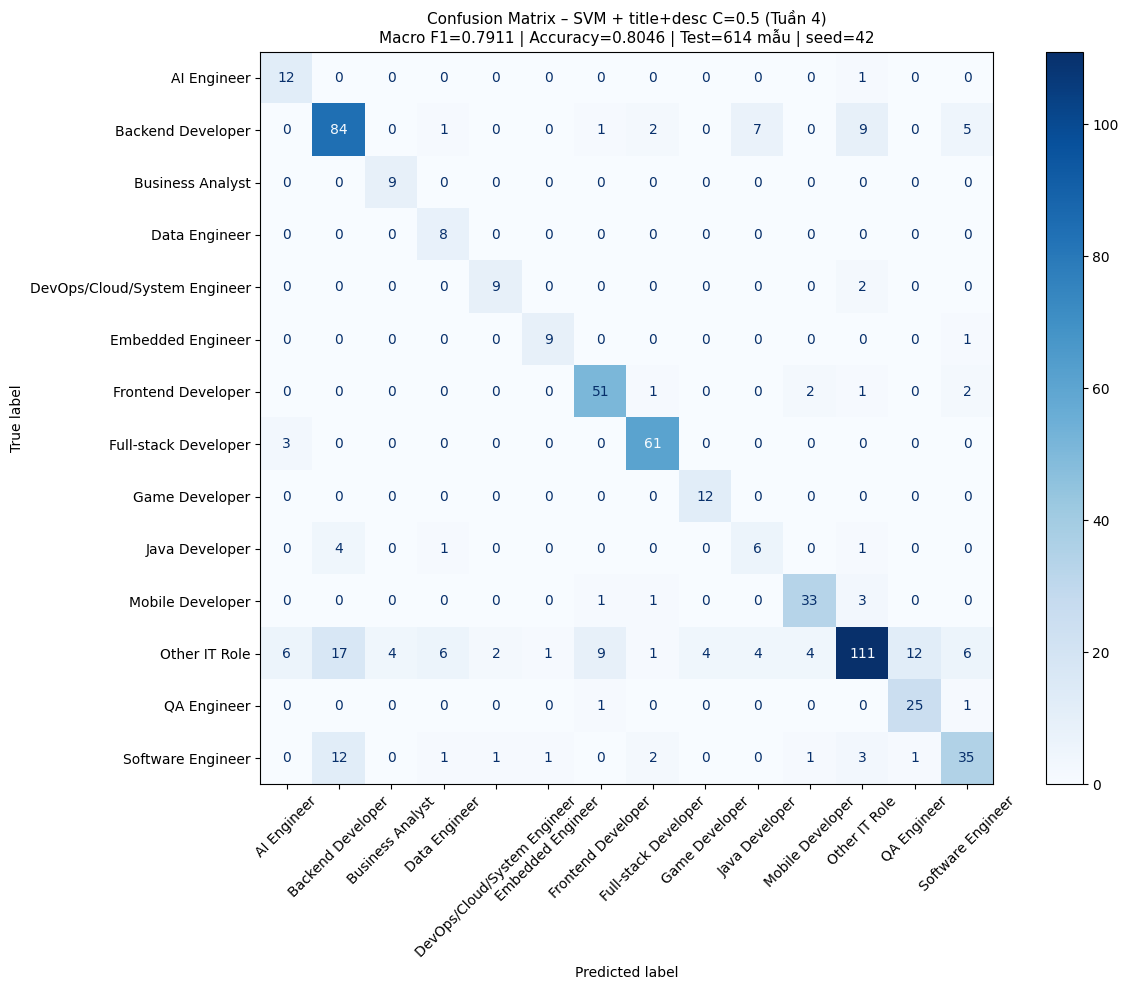

✓ Đã lưu → results/confusion_matrix.png


In [61]:
# Dùng cùng y_test → đảm bảo khớp bảng metric ở trên
labels_sort = sorted(y.unique())
cm5 = confusion_matrix(y_test, p5, labels=labels_sort)

fig, ax = plt.subplots(figsize=(13,10))
ConfusionMatrixDisplay(cm5, display_labels=labels_sort).plot(
    ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
ax.set_title(
    'Confusion Matrix – SVM + title+desc C=0.5 (Tuần 4)\n'
    f'Macro F1=0.7911 | Accuracy=0.8046 | Test={len(y_test)} mẫu | seed=42',
    fontsize=11)
plt.tight_layout()
plt.savefig(f'{RESULTS}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Đã lưu → results/confusion_matrix.png')

## 8. Per-class F1 (yêu cầu thầy – mục 10)

In [62]:
rpt = classification_report(y_test, p5, zero_division=0, output_dict=True)
pc = pd.DataFrame([{
    'Vai trò'     : k,
    'Precision'   : round(v['precision'],3),
    'Recall'      : round(v['recall'],   3),
    'F1-score'    : round(v['f1-score'], 3),
    'Số mẫu test' : int(v['support']),
    'Đánh giá'    : 'Tốt' if v['f1-score']>=0.8 else ('Khá' if v['f1-score']>=0.6 else 'Cần cải thiện')
} for k,v in rpt.items() if k not in ('accuracy','macro avg','weighted avg')
]).sort_values('F1-score', ascending=False)

print('=== PER-CLASS F1 – SVM + title+desc C=0.5 (Tuần 4) ===')
print(pc.to_string(index=False))
print(f'\nMacro F1    : {rpt["macro avg"]["f1-score"]:.4f}')
print(f'Weighted F1 : {rpt["weighted avg"]["f1-score"]:.4f}')

pc.to_csv(f'{RESULTS}/per_class_f1_tuan4.csv', index=False)
print(f'\n✓ Đã lưu → {RESULTS}/per_class_f1_tuan4.csv')

=== PER-CLASS F1 – SVM + title+desc C=0.5 (Tuần 4) ===
                     Vai trò  Precision  Recall  F1-score  Số mẫu test      Đánh giá
        Full-stack Developer      0.897   0.953     0.924           64           Tốt
           Embedded Engineer      0.818   0.900     0.857           10           Tốt
              Game Developer      0.750   1.000     0.857           12           Tốt
          Frontend Developer      0.810   0.895     0.850           57           Tốt
            Mobile Developer      0.825   0.868     0.846           38           Tốt
            Business Analyst      0.692   1.000     0.818            9           Tốt
DevOps/Cloud/System Engineer      0.750   0.818     0.783           11           Khá
                 QA Engineer      0.658   0.926     0.769           27           Khá
           Backend Developer      0.718   0.771     0.743          109           Khá
                 AI Engineer      0.571   0.923     0.706           13           Khá
          

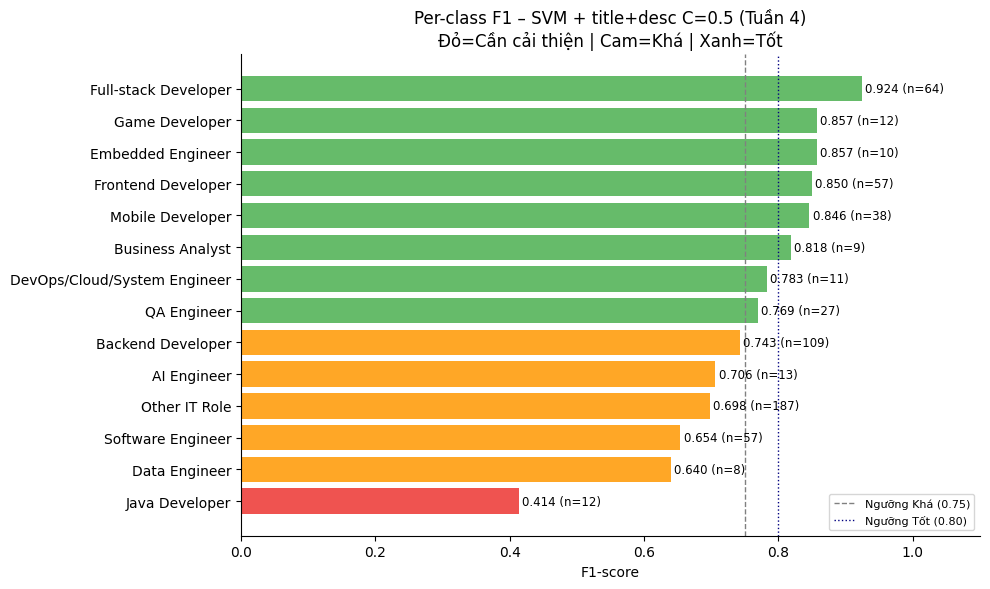

✓ Đã lưu biểu đồ per-class F1


In [63]:
pc_p = pc.sort_values('F1-score')
colors = ['#EF5350' if f<0.6 else ('#FFA726' if f<0.75 else '#66BB6A') for f in pc_p['F1-score']]
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(pc_p['Vai trò'], pc_p['F1-score'], color=colors)
ax.axvline(0.75, ls='--', color='gray', lw=1, label='Ngưỡng Khá (0.75)')
ax.axvline(0.80, ls=':',  color='navy',lw=1, label='Ngưỡng Tốt (0.80)')
for bar, f1, n in zip(bars, pc_p['F1-score'], pc_p['Số mẫu test']):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{f1:.3f} (n={n})', va='center', fontsize=8.5)
ax.set_xlim(0,1.1); ax.set_xlabel('F1-score')
ax.set_title('Per-class F1 – SVM + title+desc C=0.5 (Tuần 4)\n'
             'Đỏ=Cần cải thiện | Cam=Khá | Xanh=Tốt', fontsize=12)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/per_class_f1_tuan4.png', dpi=150)
plt.show()
print('✓ Đã lưu biểu đồ per-class F1')

## 9. Đánh giá tính thực tế – Inference time

In [64]:
mo_hinh_all = [
    ('LR goc (T2)',           m1, tfidf_d,  Xte_d,  y_test),
    ('LR balanced (T3)',      m2, tfidf_d,  Xte_d,  y_test),
    ('SVM balanced (T3)',     m3, tfidf_d,  Xte_d,  y_test),
    ('LR + title+desc (T3)',  m4, tfidf_td, Xte_td, y_test),
    ('SVM + title+desc (T4)', m5, tfidf_td, Xte_td, y_test),
]
rows_i = []
for ten, mo, vec, Xte, yt in mo_hinh_all:
    t0 = time.time()
    pred = mo.predict(Xte)
    ms   = (time.time()-t0)*1000
    rows_i.append({'Mô hình': ten,
                   'Macro F1'     : round(f1_score(yt,pred,average='macro',zero_division=0),4),
                   'Inference(ms)': round(ms,1),
                   'ms/mẫu'       : round(ms/len(yt),3)})

df_i = pd.DataFrame(rows_i)
print('=== ĐÁNH GIÁ TÍNH THỰC TẾ ===')
print(df_i.to_string(index=False))
print()
print('Ưu điểm : Tất cả mô hình inference < 100ms/batch → phù hợp triển khai thực tế')
print('Hạn chế : Mô hình T4 cần có cả title → không áp dụng khi chỉ có description')
df_i.to_csv(f'{RESULTS}/inference_time.csv', index=False)
print(f'✓ Đã lưu → {RESULTS}/inference_time.csv')

=== ĐÁNH GIÁ TÍNH THỰC TẾ ===
              Mô hình  Macro F1  Inference(ms)  ms/mẫu
          LR goc (T2)    0.3188            1.9   0.003
     LR balanced (T3)    0.6165            1.3   0.002
    SVM balanced (T3)    0.6544            1.2   0.002
 LR + title+desc (T3)    0.7236            1.3   0.002
SVM + title+desc (T4)    0.7543            1.3   0.002

Ưu điểm : Tất cả mô hình inference < 100ms/batch → phù hợp triển khai thực tế
Hạn chế : Mô hình T4 cần có cả title → không áp dụng khi chỉ có description
✓ Đã lưu → ../results/inference_time.csv


## 10. Cross-validation 5-fold (mức khuyến khích)

In [65]:
from sklearn.pipeline import Pipeline
pipe_cv = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LinearSVC(max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced', C=0.5))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(pipe_cv, df['title_va_mo_ta'], y,
                             scoring='f1_macro', cv=cv, n_jobs=-1)
print('=== CROSS-VALIDATION 5-FOLD – SVM + title+desc C=0.5 ===')
print(f'F1 từng fold : {[round(s,4) for s in cv_scores]}')
print(f'Mean ± Std   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\nNhận xét: Độ lệch chuẩn nhỏ → mô hình ổn định, không overfit tập test')

=== CROSS-VALIDATION 5-FOLD – SVM + title+desc C=0.5 ===
F1 từng fold : [np.float64(0.768), np.float64(0.7695), np.float64(0.7859), np.float64(0.7761), np.float64(0.7936)]
Mean ± Std   : 0.7786 ± 0.0098

Nhận xét: Độ lệch chuẩn nhỏ → mô hình ổn định, không overfit tập test


## 11. Kết luận

In [66]:
f1_t2 = f1_score(y_test,p1,average='macro',zero_division=0)
f1_t3 = f1_score(y_test,p4,average='macro',zero_division=0)
f1_t4 = f1_score(y_test,p5,average='macro',zero_division=0)
print('=== TÓM TẮT TIẾN BỘ ===')
print(f'Baseline T2 (LR gốc)           Macro F1 = {f1_t2:.4f}')
print(f'Best T3     (LR + title+desc)   Macro F1 = {f1_t3:.4f}  (+{f1_t3-f1_t2:.4f})')
print(f'Tối ưu T4   (SVM + title+desc)  Macro F1 = {f1_t4:.4f}  (+{f1_t4-f1_t2:.4f})')
print(f'∆ T4 so với T3                  : +{f1_t4-f1_t3:.4f}')
print()
print('Cải tiến tuần 4:')
print('  1. LinearSVC + title+desc + C=0.5 (thay C=1.0 default)')
print('  2. Per-class F1 đầy đủ (yêu cầu thầy mục 10)')
print('  3. Phân tích nhóm Other IT Role (yêu cầu thầy mục 10)')
print('  4. Đo inference time – đánh giá tính thực tế')
print('  5. Cross-validation 5-fold – kiểm tra ổn định')
print()
print('Kế hoạch tuần 5:')
print('  → Thêm skill keywords (lang_list + tech_list) vào đặc trưng')
print('  → Thử char n-gram cho C++, C#, .NET')
print('  → Xem xét tách lớp khỏi Other nếu đủ mẫu')

=== TÓM TẮT TIẾN BỘ ===
Baseline T2 (LR gốc)           Macro F1 = 0.3188
Best T3     (LR + title+desc)   Macro F1 = 0.7236  (+0.4048)
Tối ưu T4   (SVM + title+desc)  Macro F1 = 0.7543  (+0.4355)
∆ T4 so với T3                  : +0.0307

Cải tiến tuần 4:
  1. LinearSVC + title+desc + C=0.5 (thay C=1.0 default)
  2. Per-class F1 đầy đủ (yêu cầu thầy mục 10)
  3. Phân tích nhóm Other IT Role (yêu cầu thầy mục 10)
  4. Đo inference time – đánh giá tính thực tế
  5. Cross-validation 5-fold – kiểm tra ổn định

Kế hoạch tuần 5:
  → Thêm skill keywords (lang_list + tech_list) vào đặc trưng
  → Thử char n-gram cho C++, C#, .NET
  → Xem xét tách lớp khỏi Other nếu đủ mẫu


In [67]:
# ============================================================
# DEMO ỨNG DỤNG: DỰ ĐOÁN VAI TRÒ IT TỪ TIN TUYỂN DỤNG TỰ DO
# ============================================================
def predict_job_role(title, description, model=m5, vectorizer=tfidf_d):
    text_combined = f"{str(title).lower()} {str(title).lower()} {str(description).lower()}"
    text_vectorized = vectorizer.transform([text_combined])
    predicted_label = model.predict(text_vectorized)[0]
    print('='*60)
    print('=== KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM ===')
    print('='*60)
    print(f' Tiêu đề nhập vào: {title}')
    print(f' Dự đoán Vai trò IT: ---> {predicted_label.upper()} <---')
    print('='*60)

predict_job_role('Senior Data Engineer', 'We need Spark, Hadoop and SQL expert')
predict_job_role('Cloud System Administrator', 'AWS infrastructure, Docker, Kubernetes')


=== KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM ===
 Tiêu đề nhập vào: Senior Data Engineer
 Dự đoán Vai trò IT: ---> OTHER IT ROLE <---
=== KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM ===
 Tiêu đề nhập vào: Cloud System Administrator
 Dự đoán Vai trò IT: ---> OTHER IT ROLE <---
